In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [147]:



# # Logical mapping function
def assign_indian_operator(row):
     if row['InternetService'] == 'Fiber optic':
         return 'Reliance Jio'
     elif row['InternetService'] == 'DSL':
         return 'Airtel'
     elif row['PhoneService'] == 'Yes' and row['MultipleLines'] == 'Yes':
         return 'Vodafone Idea'
     else:
         return 'BSNL'

# # Create the column
df['telecom_partner'] = df.apply(assign_indian_operator, axis=1)



In [148]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [149]:
#handling missing values

df['TotalCharges'].isnull().sum()

np.int64(11)

In [150]:
df['T_MODE'] = df['TotalCharges'].fillna(df['TotalCharges'].mode()[0])
df = df.drop('TotalCharges',axis=1)

In [151]:
df['T_MODE'].isnull().sum()

np.int64(0)

In [152]:
X=df.drop('Churn',axis=1)
y=df['Churn']


In [153]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [155]:
X_train_nums_cols = X_train.select_dtypes(exclude=object)
X_train_cats_cols = X_train.select_dtypes(include=object)

X_test_nums_cols = X_test.select_dtypes(exclude=object)
X_test_cats_cols = X_test.select_dtypes(include=object)


In [156]:
print(X_train_nums_cols.columns)
print(X_train_nums_cols.shape)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'T_MODE'], dtype='object')
(5634, 4)


In [157]:
# Here applying the variable Transformation

In [158]:
#is used to check the numerical data is following the normal distribution or not

In [159]:
X_train_nums_cols

,SeniorCitizen,tenure,MonthlyCharges,T_MODE
4922,0,61,59.80,3641.50
2512,0,23,68.75,1689.45
5816,0,3,44.60,122.70
6418,0,31,79.30,2484.00
131,0,25,58.60,1502.65
...,...,...,...,...
4703,1,24,78.85,1772.25
3616,1,69,87.30,6055.55
6012,0,5,83.60,404.20
5763,0,3,70.25,229.70


In [160]:
import seaborn as sns
from scipy import stats

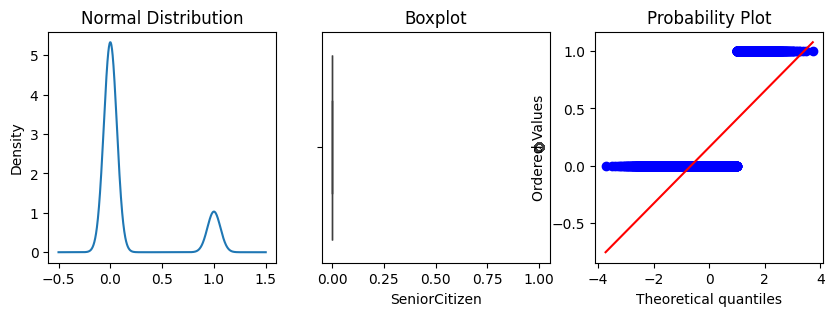

In [161]:
def fun(data,var):
  plt.figure(figsize=(10,3))
  plt.subplot(1,3,1)
  plt.title("Normal Distribution")
  data[var].plot(kind='kde')


  plt.subplot(1,3,2)
  plt.title('Boxplot')
  sns.boxplot(x=data[var])

  plt.subplot(1,3,3)
  plt.title("probplot")
  stats.probplot(data[var] , dist="norm" , plot = plt)

  plt.show()

fun(df,'SeniorCitizen')

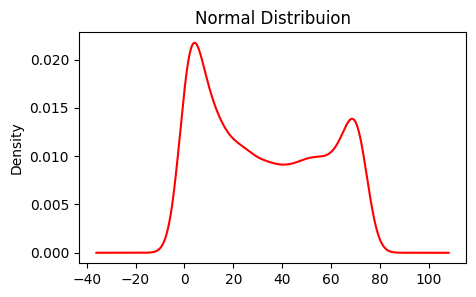

In [162]:
plt.figure(figsize=(5,3))
plt.title('Normal Distribuion')
X_train_nums_cols['tenure'].plot(kind='kde',color='r',label='original')
plt.show()

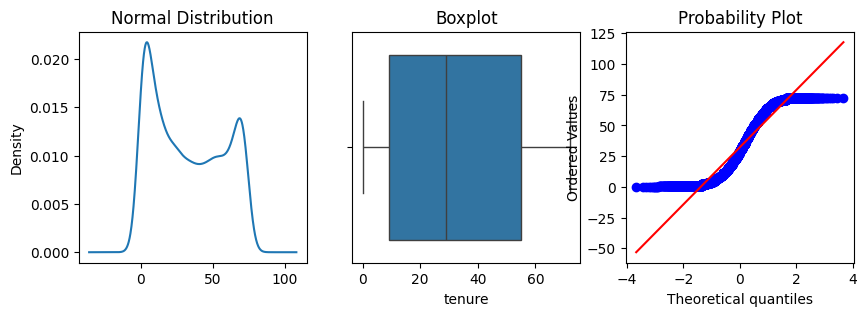

In [163]:
fun(X_train_nums_cols,'tenure')

In [164]:
#1.log

X_train_nums_cols['tenure_log'] = np.log(X_train_nums_cols['tenure']+1)




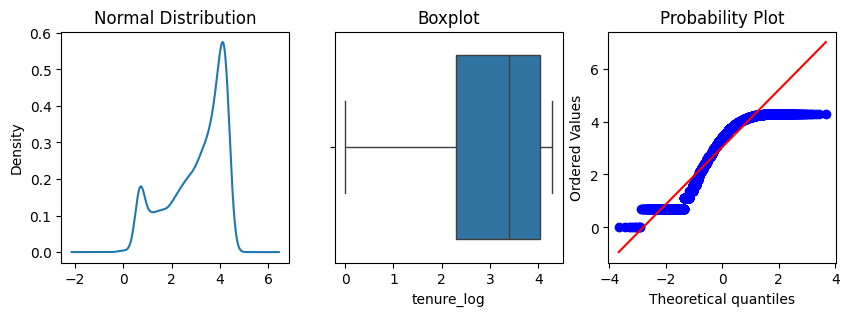

In [165]:
fun(X_train_nums_cols,'tenure_log')

In [166]:
#2. reciporcal transformation
X_train_nums_cols['tenure_rec'] = 1 / (X_train_nums_cols['tenure']+1)

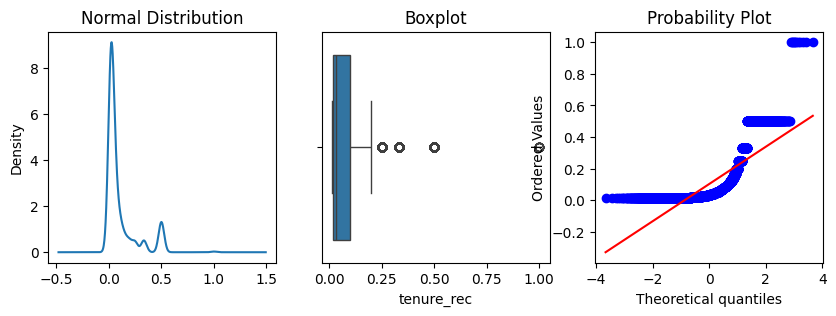

In [167]:
fun(X_train_nums_cols,'tenure_rec')

In [168]:
#3. Sqrt transformation

X_train_nums_cols['tenure_ssqrt'] = np.sqrt(X_train_nums_cols['tenure'])

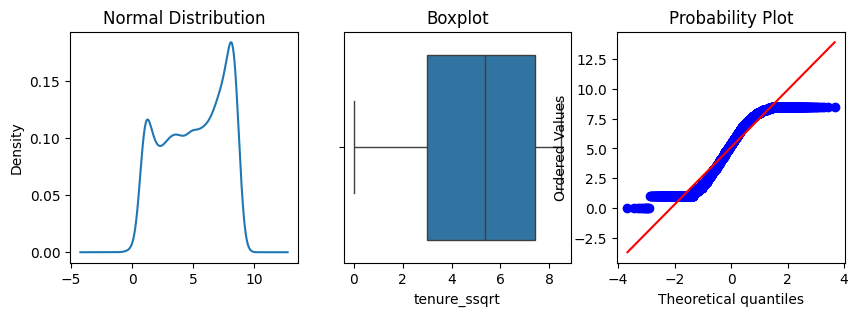

In [169]:
fun(X_train_nums_cols,'tenure_ssqrt')

In [170]:
# exponential transformation

X_train_nums_cols['tenure_exp'] = np.exp(df['tenure'])

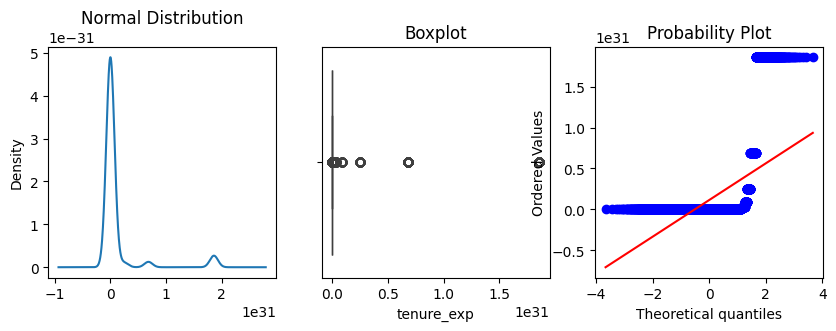

In [171]:
fun(X_train_nums_cols,'tenure_exp')

In [172]:
# Boxcox transformation

from scipy.stats import boxcox

X_train_nums_cols['tenure_boxcox'], lamdba_value = boxcox(X_train_nums_cols['tenure'] + 1)

In [173]:
lamdba_value

np.float64(0.44350451931801926)

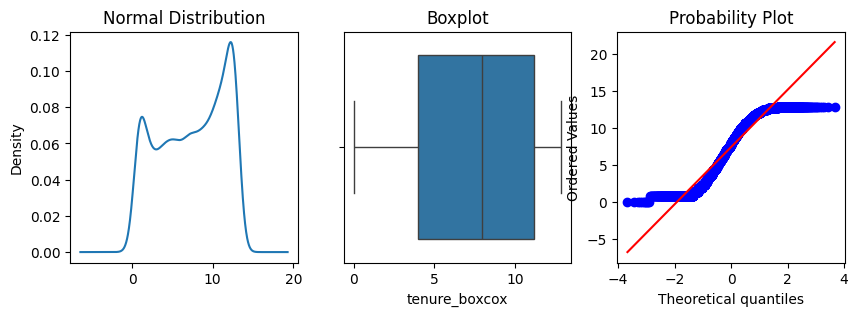

In [174]:
fun(X_train_nums_cols,'tenure_boxcox')

In [175]:
# yeojohnson transformation

from scipy.stats import yeojohnson

X_train_nums_cols['tenure_yeo'],lamda_value = yeojohnson(X_train_nums_cols['tenure'])

In [176]:
lamda_value

np.float64(0.44350453579308236)

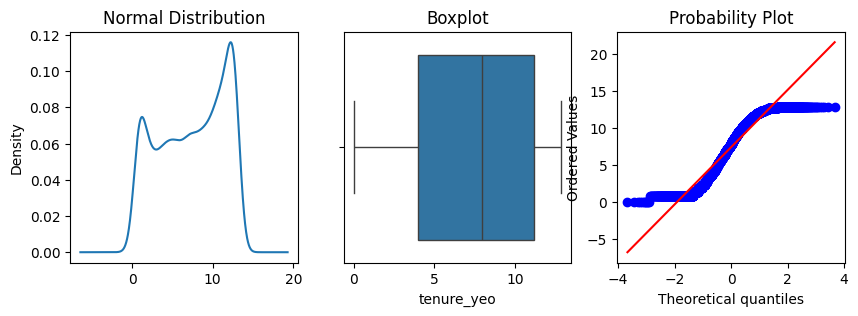

In [177]:
fun(X_train_nums_cols,'tenure_yeo')

In [178]:
#arcsine

X_train_nums_cols['tenure_arcsin'] = np.arcsin(X_train_nums_cols['tenure'])

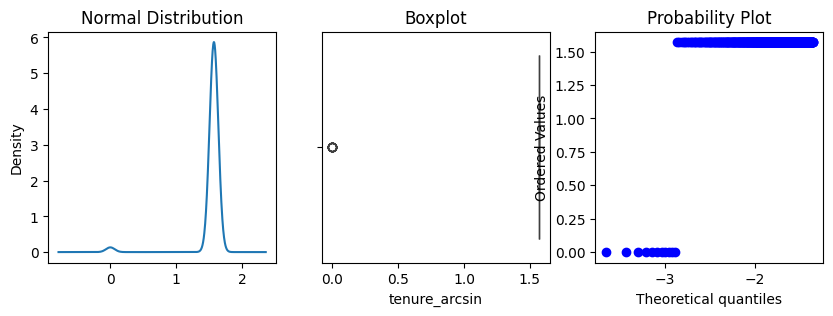

In [179]:
fun(X_train_nums_cols,'tenure_arcsin')

In [180]:
X_train_nums_cols['tenure_cube'] = X_train_nums_cols['tenure'] ** (1/3)

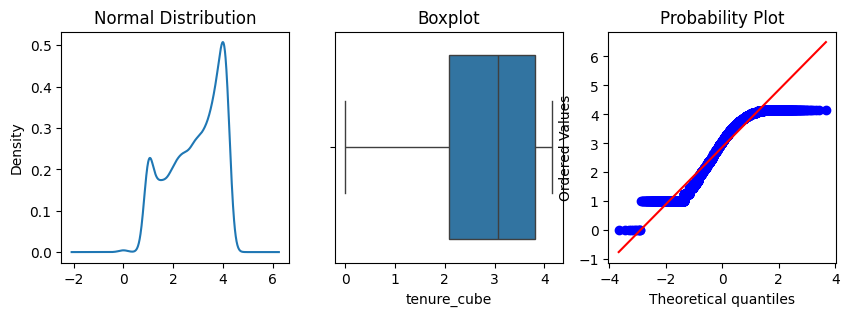

In [181]:
fun(X_train_nums_cols,'tenure_cube')

In [182]:


X_train_nums_cols['tenure_log1p'] = np.log1p(X_train_nums_cols['tenure'])

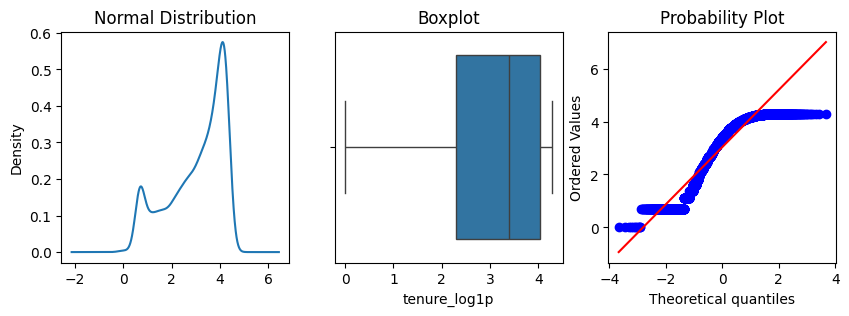

In [183]:
fun(X_train_nums_cols,'tenure_log1p')

In [184]:
X_train_nums_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'T_MODE', 'tenure_log',
       'tenure_rec', 'tenure_ssqrt', 'tenure_exp', 'tenure_boxcox',
       'tenure_yeo', 'tenure_arcsin', 'tenure_cube', 'tenure_log1p'],
      dtype='object')

In [185]:
d =[]
transformed_cols = ['tenure', 'tenure_log',
       'tenure_rec', 'tenure_ssqrt', 'tenure_exp', 'tenure_boxcox',
       'tenure_yeo', 'tenure_arcsin', 'tenure_cube','tenure_log1p'
]

d.append(X_train_nums_cols[transformed_cols].skew())

for i in d:
  print(abs(i))

tenure           0.245948
tenure_log       0.777004
tenure_rec       2.145664
tenure_ssqrt     0.231576
tenure_exp       3.789981
tenure_boxcox    0.241001
tenure_yeo       0.241001
tenure_arcsin    6.544017
tenure_cube      0.458845
tenure_log1p     0.777004
dtype: float64


In [186]:
X_train_nums_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'T_MODE', 'tenure_log',
       'tenure_rec', 'tenure_ssqrt', 'tenure_exp', 'tenure_boxcox',
       'tenure_yeo', 'tenure_arcsin', 'tenure_cube', 'tenure_log1p'],
      dtype='object')

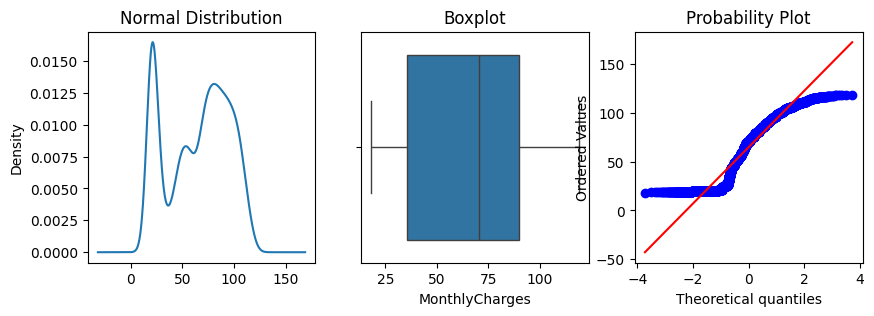

In [187]:
fun(df,'MonthlyCharges') # original

In [188]:
#boxcox
from scipy.stats import boxcox

df['MonthlyCharges_box'],lamb = boxcox(df['MonthlyCharges'])

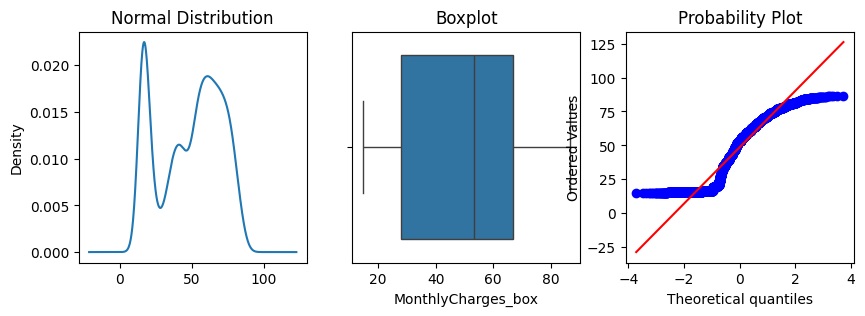

In [189]:
fun(df,'MonthlyCharges_box')

In [190]:
#log
df['MonthlyCharges_log'] = np.log(df['MonthlyCharges'])

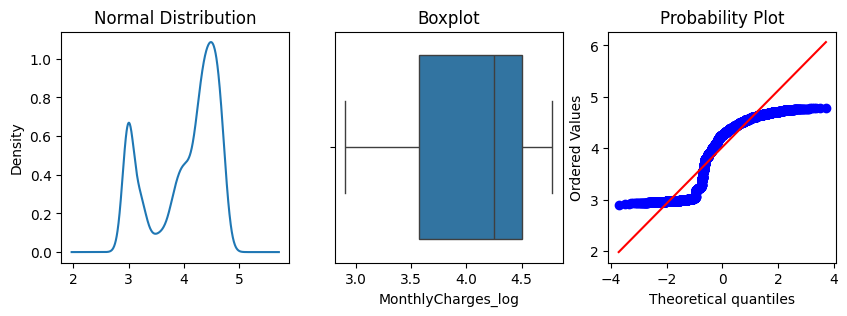

In [191]:
fun(df,'MonthlyCharges_log')

In [192]:
#yeojohnson
from scipy.stats import yeojohnson

X_train_nums_cols['MonthlyCharges_yeo'], lambda_mc = yeojohnson(X_train_nums_cols['MonthlyCharges'])

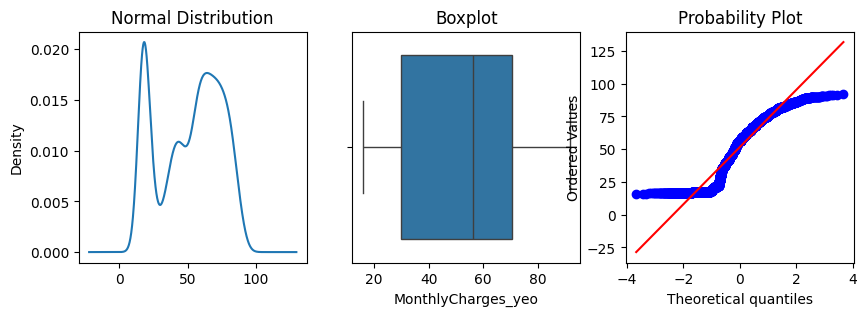

In [193]:
fun(X_train_nums_cols,'MonthlyCharges_yeo')

In [194]:
#reciporical

X_train_nums_cols['MonthlyCharges_rec'] = 1 / (X_train_nums_cols['MonthlyCharges'])

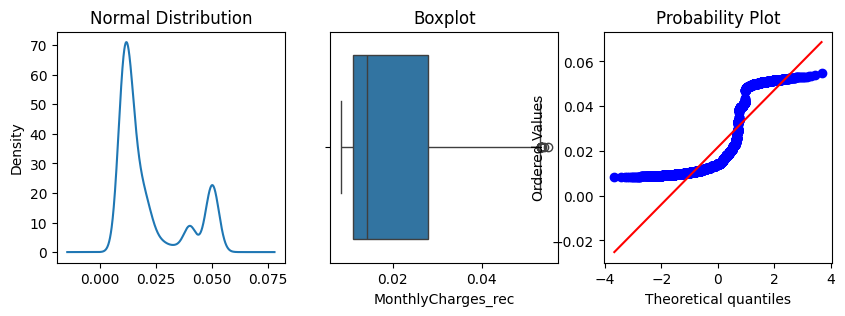

In [195]:
fun(X_train_nums_cols,'MonthlyCharges_rec')

In [196]:
X_train_nums_cols['MonthlyCharges_sqrt'] = np.sqrt(X_train_nums_cols['MonthlyCharges'])

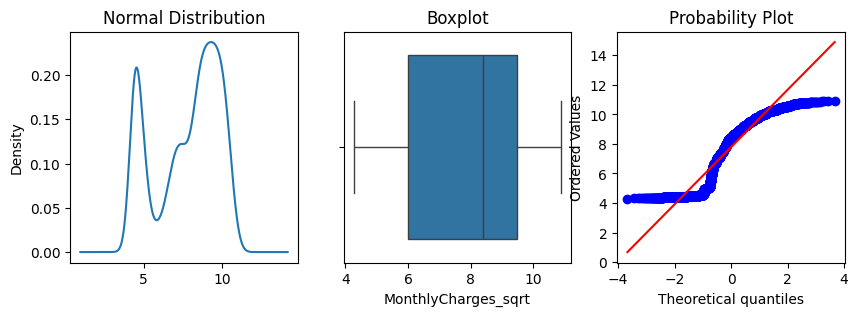

In [197]:
fun(X_train_nums_cols,'MonthlyCharges_sqrt')

In [198]:
#expon

X_train_nums_cols['MonthlyCharges_exp']=np.exp(X_train_nums_cols['MonthlyCharges'])

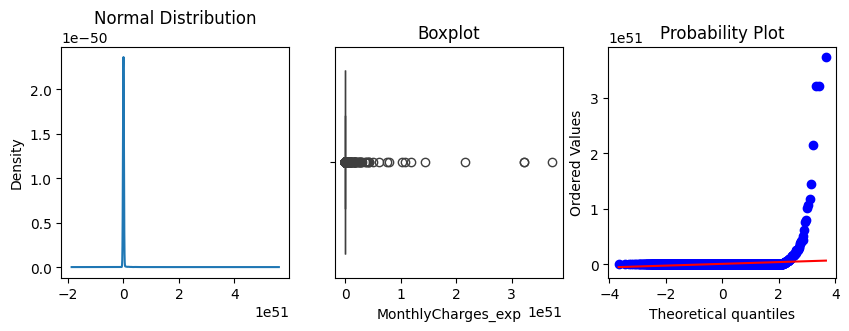

In [199]:
fun(X_train_nums_cols,'MonthlyCharges_exp')

In [200]:
#arcsin

X_train_nums_cols['MonthlyCharges_arcsin']=np.arcsin(X_train_nums_cols['MonthlyCharges']+1)

In [201]:
X_train_nums_cols

,SeniorCitizen,tenure,MonthlyCharges,T_MODE,tenure_log,tenure_rec,tenure_ssqrt,tenure_exp,tenure_boxcox,tenure_yeo,tenure_arcsin,tenure_cube,tenure_log1p,MonthlyCharges_yeo,MonthlyCharges_rec,MonthlyCharges_sqrt,MonthlyCharges_exp,MonthlyCharges_arcsin
4922,0,61,59.80,3641.50,4.127134,0.016129,7.810250,3.104298e+26,11.806865,11.806865,NaN,3.936497,4.127134,48.275940,0.016722,7.733046,9.349966e+25,NaN
2512,0,23,68.75,1689.45,3.178054,0.041667,4.795832,9.744803e+09,6.975873,6.975873,NaN,2.843867,3.178054,55.014625,0.014545,8.291562,7.206852e+29,NaN
5816,0,3,44.60,122.70,1.386294,0.250000,1.732051,2.008554e+01,1.915061,1.915061,NaN,1.442250,1.386294,36.669120,0.022422,6.678323,2.341714e+19,NaN
6418,0,31,79.30,2484.00,3.465736,0.031250,5.567764,2.904885e+13,8.232026,8.232027,NaN,3.141381,3.465736,62.883252,0.012610,8.905055,2.751392e+34,NaN
131,0,25,58.60,1502.65,3.258097,0.038462,5.000000,7.200490e+10,7.309440,7.309440,NaN,2.924018,3.258097,47.367499,0.017065,7.655064,2.816156e+25,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4703,1,24,78.85,1772.25,3.218876,0.040000,4.898979,2.648912e+10,7.144513,7.144513,NaN,2.884499,3.218876,62.549125,0.012682,8.879752,1.754365e+34,NaN
3616,1,69,87.30,6055.55,4.248495,0.014286,8.306624,9.253782e+29,12.584458,12.584459,NaN,4.101566,4.248495,68.802734,0.011455,9.343447,8.201783e+37,NaN
6012,0,5,83.60,404.20,1.791759,0.166667,2.236068,1.484132e+02,2.736553,2.736553,NaN,1.709976,1.791759,66.069712,0.011962,9.143304,2.027770e+36,NaN
5763,0,3,70.25,229.70,1.386294,0.250000,1.732051,2.008554e+01,1.915061,1.915061,NaN,1.442250,1.386294,56.138059,0.014235,8.381527,3.229887e+30,NaN


In [202]:
#fun(X_train_nums_cols,'MonthlyCharges_arcsin')

In [203]:
import warnings
warnings.filterwarnings('ignore')

In [204]:
X_train_nums_cols['MonthlyCharges_cube'] = X_train_nums_cols['MonthlyCharges'] ** (1/3)

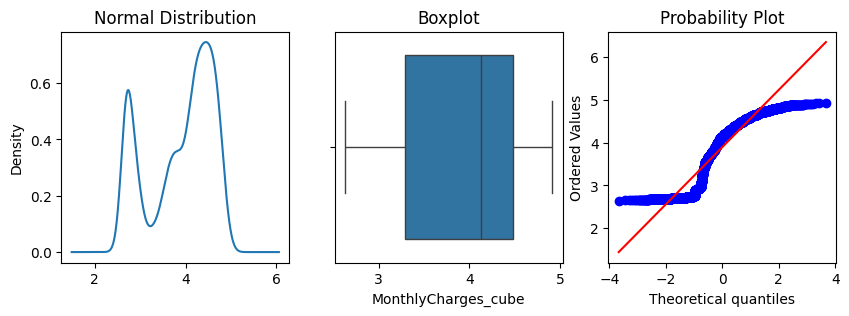

In [205]:
fun(X_train_nums_cols,'MonthlyCharges_cube')

In [206]:
X_train_nums_cols['MonthlyCharges_log1p'] = np.log(1+X_train_nums_cols['MonthlyCharges'])

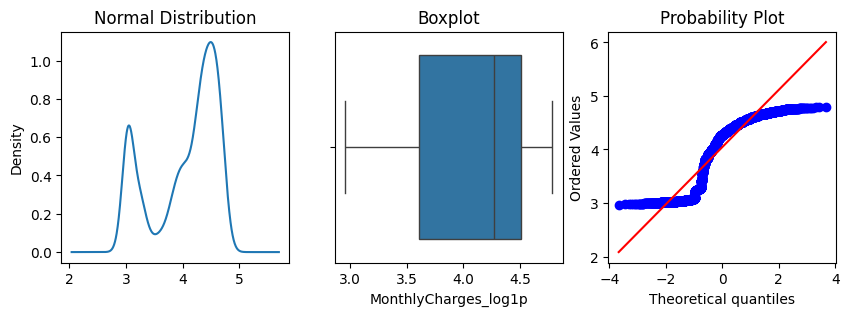

In [207]:
fun(X_train_nums_cols,'MonthlyCharges_log1p')

In [208]:
X_train_nums_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'T_MODE', 'tenure_log',
       'tenure_rec', 'tenure_ssqrt', 'tenure_exp', 'tenure_boxcox',
       'tenure_yeo', 'tenure_arcsin', 'tenure_cube', 'tenure_log1p',
       'MonthlyCharges_yeo', 'MonthlyCharges_rec', 'MonthlyCharges_sqrt',
       'MonthlyCharges_exp', 'MonthlyCharges_arcsin', 'MonthlyCharges_cube',
       'MonthlyCharges_log1p'],
      dtype='object')

In [209]:
e =[]
transformed_cols = ['MonthlyCharges','MonthlyCharges_yeo', 'MonthlyCharges_rec', 'MonthlyCharges_sqrt',
       'MonthlyCharges_exp',
       'MonthlyCharges_cube'
]

e.append(X_train_nums_cols[transformed_cols].skew())

for i in e:
  print(abs(i))

MonthlyCharges          0.223757
MonthlyCharges_yeo      0.259489
MonthlyCharges_rec      1.113589
MonthlyCharges_sqrt     0.488366
MonthlyCharges_exp     30.141329
MonthlyCharges_cube     0.573114
dtype: float64


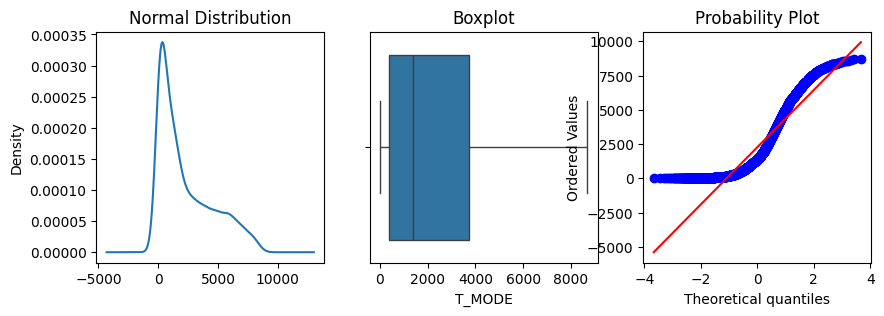

In [210]:
fun(X_train_nums_cols,'T_MODE')

In [211]:
#1.log

X_train_nums_cols['Totalcharges_log'] = np.log(X_train_nums_cols['T_MODE']+1)




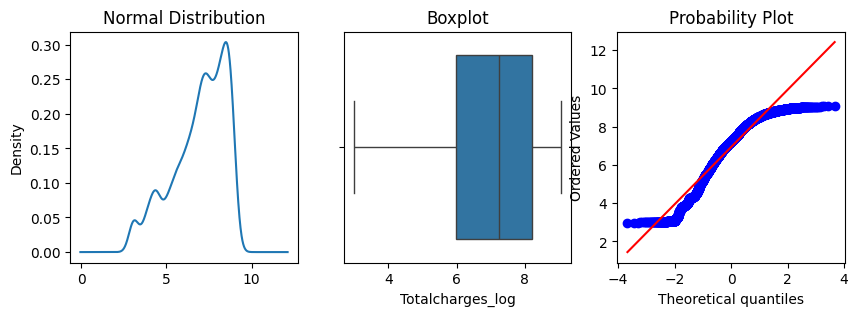

In [212]:
fun(X_train_nums_cols,'Totalcharges_log')

In [213]:
#2. reciporcal transformation
X_train_nums_cols['TotalCharges_rec'] = 1 / (X_train_nums_cols['T_MODE']+1)

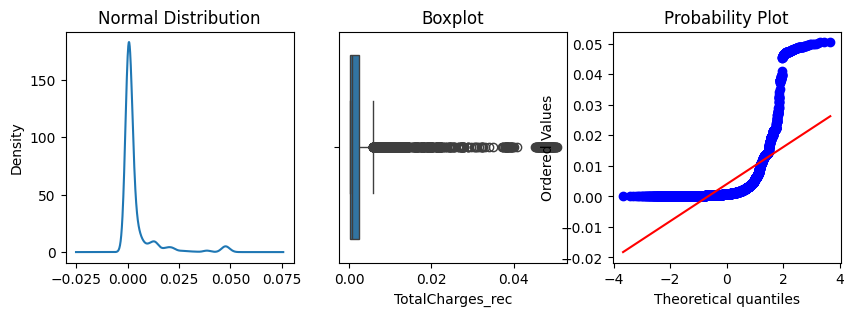

In [214]:
fun(X_train_nums_cols,'TotalCharges_rec')

In [215]:
#3. Sqrt transformation

X_train_nums_cols['TotalCharges_sqrt'] = np.sqrt(X_train_nums_cols['T_MODE'])

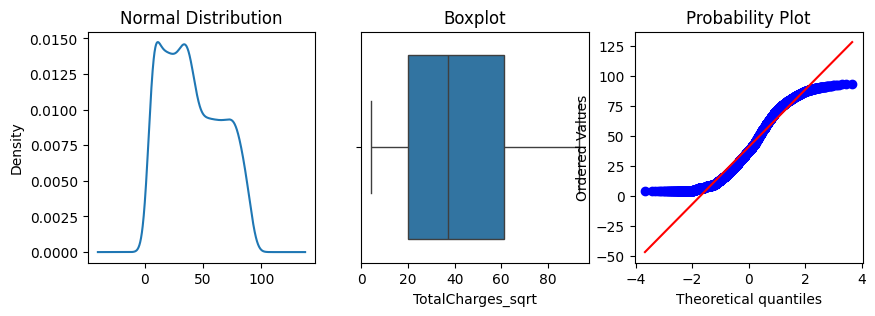

In [216]:
fun(X_train_nums_cols,'TotalCharges_sqrt')

In [217]:
# exponential transformation

X_train_nums_cols['TotalCharges_exp'] = np.exp(df['T_MODE'])

In [218]:
#fun(X_train_nums_cols,'TotalCharges_exp')

In [219]:
# Boxcox transformation

from scipy.stats import boxcox

X_train_nums_cols['TotalCharges_boxcox'], lamdba_value = boxcox(X_train_nums_cols['T_MODE'] + 1)

In [220]:
lamdba_value

np.float64(0.25583223572976554)

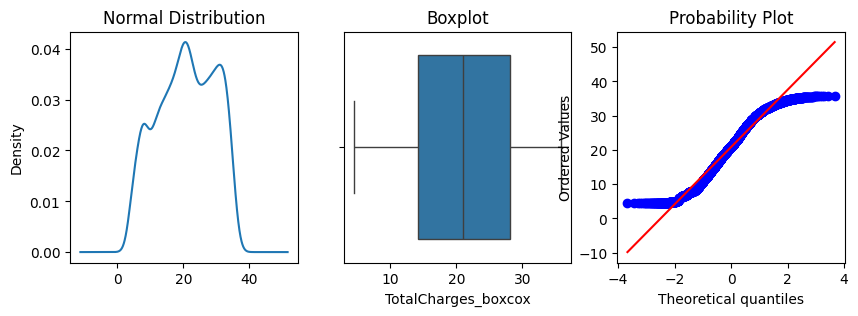

In [221]:
fun(X_train_nums_cols,'TotalCharges_boxcox')

In [222]:
# yeojohnson transformation

from scipy.stats import yeojohnson

X_train_nums_cols['TotalCharges_yeo'],lamda_value = yeojohnson(X_train_nums_cols['T_MODE'])

In [223]:
lamda_value

np.float64(0.2558322409686179)

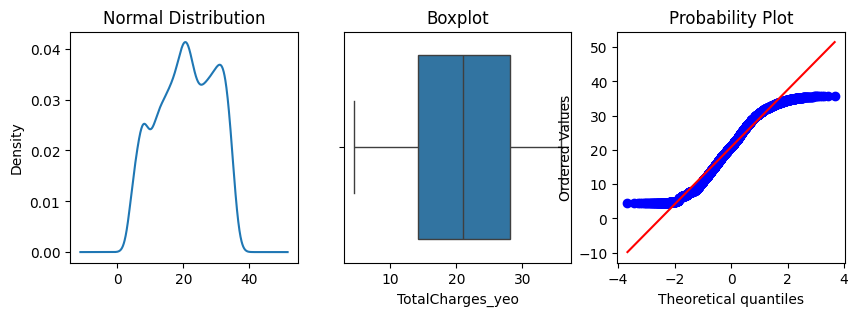

In [224]:
fun(X_train_nums_cols,'TotalCharges_yeo')

In [225]:
#arcsine

X_train_nums_cols['TotalCharges_arcsin'] = np.arcsin(X_train_nums_cols['T_MODE'])

In [226]:
#fun(X_train_nums_cols, 'TotalCharges_arcsin')

In [227]:
#cube root

X_train_nums_cols['TotalCharges_cube'] = X_train_nums_cols['T_MODE'] ** (1/3)

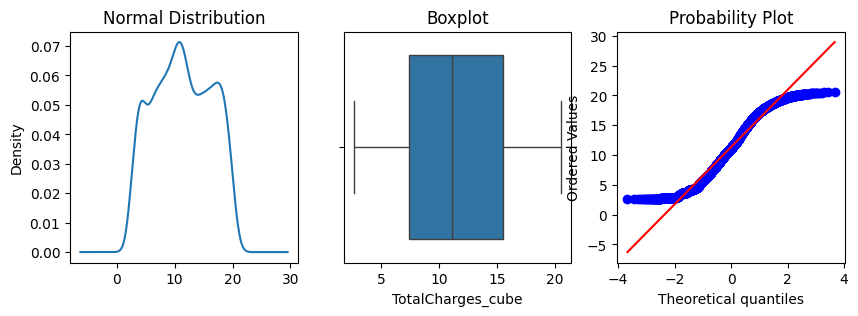

In [228]:
fun(X_train_nums_cols,'TotalCharges_cube')

In [229]:
df = pd.DataFrame()

In [230]:
X_train_nums_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'T_MODE', 'tenure_log',
       'tenure_rec', 'tenure_ssqrt', 'tenure_exp', 'tenure_boxcox',
       'tenure_yeo', 'tenure_arcsin', 'tenure_cube', 'tenure_log1p',
       'MonthlyCharges_yeo', 'MonthlyCharges_rec', 'MonthlyCharges_sqrt',
       'MonthlyCharges_exp', 'MonthlyCharges_arcsin', 'MonthlyCharges_cube',
       'MonthlyCharges_log1p', 'Totalcharges_log', 'TotalCharges_rec',
       'TotalCharges_sqrt', 'TotalCharges_exp', 'TotalCharges_boxcox',
       'TotalCharges_yeo', 'TotalCharges_arcsin', 'TotalCharges_cube'],
      dtype='object')

In [236]:
def fun1(data,var):

  plt.figure(figsize=(5,3))
  plt.title('Boxplot')
  sns.boxplot(x=data[var])

  plt.show()



In [234]:
#applying the outlier techniques

df = pd.DataFrame()
df['tenure'] = X_train_nums_cols['tenure']
df['MonthlyCharges'] = X_train_nums_cols['MonthlyCharges']
df['T_MODE'] = X_train_nums_cols['T_MODE']


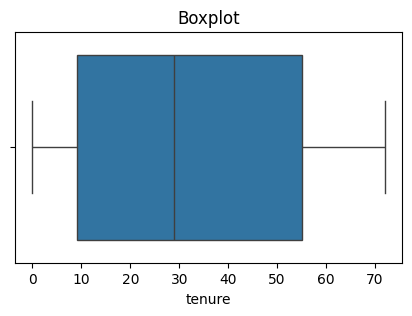

In [237]:
fun1(df,'tenure')

In [238]:
# applying outlier technique with winzorization with gaussian
k = 3

lower = df['tenure'].mean() - k * df['tenure'].std()
upper = df['tenure'].mean() + k * df['tenure'].std()

df['tenure_win_gau'] = df['tenure'].clip(lower,upper)

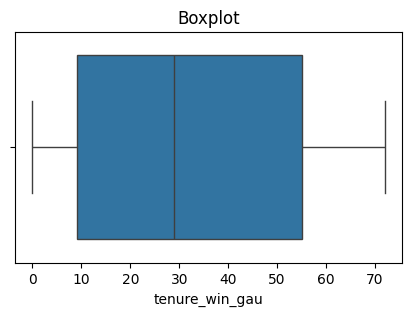

In [239]:
fun1(df,'tenure_win_gau')

In [240]:
lower

np.float64(-41.27042893276105)

In [241]:
upper

np.float64(105.75747188625768)

In [242]:
df

,tenure,MonthlyCharges,T_MODE,tenure_win_gau
4922,61,59.80,3641.50,61
2512,23,68.75,1689.45,23
5816,3,44.60,122.70,3
6418,31,79.30,2484.00,31
131,25,58.60,1502.65,25
...,...,...,...,...
4703,24,78.85,1772.25,24
3616,69,87.30,6055.55,69
6012,5,83.60,404.20,5
5763,3,70.25,229.70,3


In [ ]:
from scipy.stats.mstats import winsorize

df['tenure_win_3'] = winsorize(df['tenure'], limits=[0.03,0.03])

In [ ]:
df.sample(20)

In [ ]:
# applying the isolation forest

from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05,random_state=42)
df['tenure_outlier'] = iso.fit_predict(df[['tenure']])

In [ ]:
outliers = sum(df['tenure_outlier'] == -1)
normals = sum(df['tenure_outlier'] == 1)

In [ ]:
outliers

In [ ]:
# Start with original values
df['tenure_iso_cap'] = df['tenure']

# Cap only the outliers
lower = df['tenure'].quantile(0.03)
upper = df['tenure'].quantile(0.97)

  # df.loc[df['outlier'] == -1, 'tenure_iso_cap'] = np.clip(
  #     df.loc[df['outlier'] == -1, 'tenure'],
  #     lower,
  #     upper
  # )

df['tenure_iso_cap'] = np.where(
    df['tenure_outlier'] == -1,                   # condition: if outlier
    np.clip(df['tenure'], lower, upper),   # value if True: capped
    df['tenure']                            # value if False: keep original
)
df

In [243]:
# trimming

iqr = df['tenure'].quantile(0.75) - df['tenure'].quantile(0.25)

lower = df['tenure'].quantile(0.25) - (1.5*iqr)

upper = df['tenure'].quantile(0.75) + (1.5*iqr)

In [244]:
df['tenure_trim'] = np.where(df['tenure'] < lower, lower, np.where(df['tenure'] > upper, upper, df['tenure'] ))

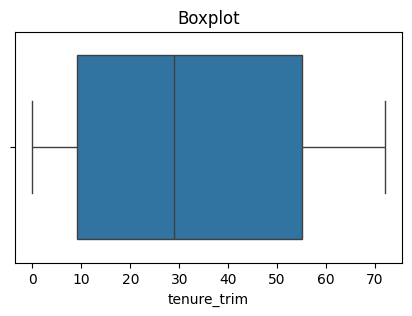

In [245]:
fun1(df,'tenure_trim')

In [ ]:
# capping with mean and std


lower1 = df['tenure'].mean() - 3 * df['tenure'].std()
upper1 = df['tenure'].mean() + 3 * df['tenure'].std()

df['tenure_cap_m_s'] = np.where(df['tenure'] < lower1, lower1, np.where(df['tenure']>upper1,upper1,df['tenure']))

In [ ]:
df

In [ ]:
# capping with 5th and 95 th quantile

lower2 = df['tenure'].quantile(0.05)
upper2 = df['tenure'].quantile(0.95)

df['tenure_cap_5_95Q'] = np.where(df['tenure'] < lower2, lower2, np.where(df['tenure']>upper2, upper2,df['tenure']))

In [ ]:
df

In [ ]:
cols = ['tenure', 'tenure_win_gau', 'tenure_win_3', 'tenure_iso_cap',
        'tenure_trim', 'tenure_cap_m_s', 'tenure_cap_5_95Q']

df[cols].describe()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
for col in cols[1:]:
    sns.kdeplot(df[col], label=col)
plt.legend()
plt.title("Distribution after different outlier treatments")
plt.show()

In [ ]:
for col in cols[1:]:
    print(col, "min:", df[col].min(), "max:", df[col].max())

In [ ]:
df['diff_win_gau'] = df['tenure'] - df['tenure_win_gau']
df['diff_win_3'] = df['tenure'] - df['tenure_win_3']
df['diff_iso'] = df['tenure'] - df['tenure_iso_cap']
df[['diff_win_gau','diff_win_3','diff_iso']].describe()

In [ ]:
df

In [ ]:
df

In [ ]:
# applying outlier technique with winzorization with gaussian
k = 3

lower = df['MonthlyCharges'].mean() - k * df['MonthlyCharges'].std()
upper = df['MonthlyCharges'].mean() + k * df['MonthlyCharges'].std()

df['MonthlyCharges_win_gau'] = df['MonthlyCharges'].clip(lower,upper)

In [ ]:
lower

In [ ]:
upper

In [ ]:
df

In [ ]:
from scipy.stats.mstats import winsorize

df['MonthlyCharges_win_3'] = winsorize(df['MonthlyCharges'], limits=[0.03,0.03])

In [ ]:
df.sample(20)

In [ ]:
# applying the isolation forest

from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05,random_state=42)
df['MonthlyCharges_outlier'] = iso.fit_predict(df[['MonthlyCharges']])
outliers1 = sum(df['MonthlyCharges_outlier'] == -1)
normals1 = sum(df['MonthlyCharges_outlier'] == 1)


In [ ]:
outliers1 = sum(df['MonthlyCharges_outlier'] == -1)
normals1 = sum(df['MonthlyCharges_outlier'] == 1)

In [ ]:
outliers1

In [ ]:
normals1

In [ ]:
# Start with original values
df['MonthlyCharges_iso_cap'] = df['MonthlyCharges']

# Cap only the outliers
lower = df['MonthlyCharges'].quantile(0.03)
upper = df['MonthlyCharges'].quantile(0.97)

  # df.loc[df['outlier'] == -1, 'tenure_iso_cap'] = np.clip(
  #     df.loc[df['outlier'] == -1, 'tenure'],
  #     lower,
  #     upper
  # )

df['MonthlyCharges_iso_cap'] = np.where(df['MonthlyCharges_outlier'] == -1,                   # condition: if outlier
    np.clip(df['MonthlyCharges'], lower, upper),   # value if True: capped
    df['MonthlyCharges']                            # value if False: keep original
)
df

In [246]:
# trimming

iqr = df['MonthlyCharges'].quantile(0.75) - df['MonthlyCharges'].quantile(0.25)

lower = df['MonthlyCharges'].quantile(0.25) - (1.5*iqr)

upper = df['MonthlyCharges'].quantile(0.75) + (1.5*iqr)

In [ ]:
df['MonthlyCharges_trim'] = np.where(df['MonthlyCharges'] < lower, lower, np.where(df['MonthlyCharges'] > upper, upper, df['MonthlyCharges'] ))

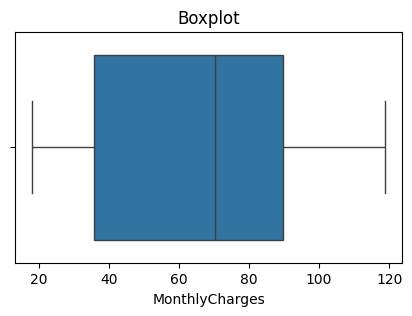

In [248]:
fun1(df,'MonthlyCharges')

In [247]:
# capping with mean and std


lower1 = df['MonthlyCharges'].mean() - 3 * df['MonthlyCharges'].std()
upper1 = df['MonthlyCharges'].mean() + 3 * df['MonthlyCharges'].std()

df['MonthlyCharges_cap_m_s'] = np.where(df['MonthlyCharges'] < lower1, lower1, np.where(df['MonthlyCharges']>upper1,upper1,df['MonthlyCharges']))

In [ ]:
df

In [ ]:
# capping with 5th and 95 th quantile

lower2 = df['MonthlyCharges'].quantile(0.05)
upper2 = df['MonthlyCharges'].quantile(0.95)

df['MonthlyCharges_cap_5_95Q'] = np.where(df['MonthlyCharges'] < lower2, lower2, np.where(df['MonthlyCharges']>upper2, upper2,df['MonthlyCharges']))

In [ ]:
df

In [ ]:
cols = ['MonthlyCharges', 'MonthlyCharges_win_gau', 'MonthlyCharges_win_3', 'MonthlyCharges_iso_cap',
        'MonthlyCharges_trim', 'MonthlyCharges_cap_m_s', 'MonthlyCharges_cap_5_95Q']

df[cols].describe()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
for col in cols[0:]:
    sns.kdeplot(df[col], label=col)
plt.legend()
plt.title("Distribution after different outlier treatments")
plt.show()

In [ ]:
df

In [ ]:
# applying outlier technique with winzorization with gaussian
k = 3

lower = df['T_MODE'].mean() - k * df['T_MODE'].std()
upper = df['T_MODE'].mean() + k * df['T_MODE'].std()

df['T_MODE_win_gau'] = df['T_MODE'].clip(lower,upper)

In [ ]:
lower

In [ ]:
upper

In [ ]:
from scipy.stats.mstats import winsorize

df['T_MODE_win_3'] = winsorize(df['T_MODE'], limits=[0.03,0.03])

In [ ]:
df.sample(5)

In [ ]:
# applying the isolation forest

from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05,random_state=42)
df['T_MODE_outlier'] = iso.fit_predict(df[['T_MODE']])
outliers1 = sum(df['T_MODE_outlier'] == -1)
normals1 = sum(df['T_MODE_outlier'] == 1)


In [ ]:
outliers1 = sum(df['T_MODE_outlier'] == -1)
normals1 = sum(df['T_MODE_outlier'] == 1)

In [ ]:
outliers1

In [ ]:
normals1

In [ ]:
# Start with original values
df['T_MODE_iso_cap'] = df['T_MODE']

# Cap only the outliers
lower = df['T_MODE'].quantile(0.03)
upper = df['T_MODE'].quantile(0.97)

  # df.loc[df['outlier'] == -1, 'tenure_iso_cap'] = np.clip(
  #     df.loc[df['outlier'] == -1, 'tenure'],
  #     lower,
  #     upper
  # )

df['T_MODE_iso_cap'] = np.where(df['T_MODE_outlier'] == -1,                   # condition: if outlier
    np.clip(df['T_MODE'], lower, upper),   # value if True: capped
    df['T_MODE']                            # value if False: keep original
)
df

In [ ]:
# trimming

iqr = df['T_MODE'].quantile(0.75) - df['T_MODE'].quantile(0.25)

lower = df['T_MODE'].quantile(0.25) - (1.5*iqr)

upper = df['T_MODE'].quantile(0.75) + (1.5*iqr)

In [ ]:
df['T_MODE_trim'] = np.where(df['T_MODE'] < lower, lower, np.where(df['T_MODE'] > upper, upper, df['T_MODE'] ))

In [ ]:
df

In [ ]:
# capping with mean and std


lower1 = df['T_MODE'].mean() - 3 * df['T_MODE'].std()
upper1 = df['T_MODE'].mean() + 3 * df['T_MODE'].std()

df['T_MODE_cap_m_s'] = np.where(df['T_MODE'] < lower1, lower1, np.where(df['T_MODE']>upper1,upper1,df['T_MODE']))

In [ ]:
df

In [ ]:
# capping with 5th and 95 th quantile

lower2 = df['T_MODE'].quantile(0.05)
upper2 = df['T_MODE'].quantile(0.95)

df['T_MODE_cap_5_95Q'] = np.where(df['T_MODE'] < lower2, lower2, np.where(df['T_MODE']>upper2, upper2,df['T_MODE']))

In [ ]:
df

In [ ]:
cols = ['T_MODE', 'T_MODE_win_gau', 'T_MODE_win_3', 'T_MODE_iso_cap',
        'T_MODE_trim', 'T_MODE_cap_m_s', 'T_MODE_cap_5_95Q']

df[cols].describe()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
for col in cols[0:]:
    sns.kdeplot(df[col], label=col)
plt.legend()
plt.title("Distribution after different outlier treatments")
plt.show()

In [ ]:
df

In [ ]:
fs=pd.DataFrame()
fs['SeniorCitizen'] = X_train_nums_cols['SeniorCitizen']
fs['tenure_trim'] = df['tenure_trim']
fs['MonthlyCharges_cap_m_s'] = df['MonthlyCharges_cap_m_s']
fs['T_MODE_cap_m_s'] = df['T_MODE_cap_m_s']



In [ ]:
fs

In [ ]:
# applying constant technique

from sklearn.feature_selection import VarianceThreshold

var = VarianceThreshold(threshold=0)
var.fit(fs)


In [ ]:
sum(var.get_support()) #good

In [ ]:
sum(~var.get_support()) #bad

In [ ]:
#applying the quasi constant

var = VarianceThreshold(threshold=0.01)
var.fit(fs)

In [ ]:
sum(var.get_support()) #good

In [ ]:
sum(~var.get_support()) #bad

In [ ]:
# apply hypothesis testing

fs['Churn'] = y_train
fs['Churn'] = fs['Churn'].map({'No': 0 , 'Yes':1}).astype(int)

#fs = fs.drop(['Churn'],axis=1)

In [ ]:
fs

In [ ]:
X = fs.iloc[:, :-1]
y = fs.iloc[:, -1]

In [ ]:
X

In [ ]:
from scipy.stats import pearsonr

c = []

for i in X.columns:
  result = pearsonr(X[i], y)
  c.append(result)

In [ ]:
c

In [ ]:
t = np.array(c)

In [ ]:
t

In [ ]:
p_values = pd.Series(t[:,1],index=X.columns)

In [ ]:
p_values

In [ ]:
f=[]
p=0
for i in p_values:
  if i < 0.05:
    f.append(X.columns[p])
  p=p+1


In [ ]:
f

In [ ]:
# Converting the categorical column to numerical column


